# COURSE: A deep understanding of deep learning
## SECTION: Generative adversarial networks
### LECTURE: CodeChallenge: CNN GAN with CIFAR
#### TEACHER: Mike X Cohen, sincxpress.com
##### COURSE URL: udemy.com/course/deeplearning_x/?couponCode=202401

In [39]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

# for importing data
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader,Subset

import sys

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [40]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Import the data

In [41]:
# Create the transformations 
transform = T.Compose([
    T.ToTensor(),
    T.Resize((64, 64)),  # Ensure images are 64x64
    T.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])

# import the data 
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
devtestset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
classes = trainset.classes

# split the devtestset into dev and test sets
devset_size = len(devtestset) * 0.7
testset_size = len(devtestset) * 0.3
randidx = np.random.permutation(len(devtestset))
devset = Subset(devtestset, randidx[:int(devset_size)])
testset = Subset(devtestset, randidx[int(devset_size):])

# Transform the datasets into dataloaders
batch_size = 64
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
dev_loader = DataLoader(devset, batch_size=batch_size, shuffle=False, num_workers=2, drop_last=True)
test_loader = DataLoader(testset, batch_size=len(testset), shuffle=False, num_workers=2)



Files already downloaded and verified
Files already downloaded and verified


# Play with the data

In [42]:
print(f"Train set size: {len(trainset)}")
print(f"Dev set size: {len(devset)}")
print(f"Test set size: {len(testset)}")

X,y = next(iter(train_loader))
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Numbers of first value in X: {X[0,0,:,:].numpy().flatten()[:10]}")
print(f"Class of X: {trainset.classes[y[0]]}")

print(f"Classes: {trainset.classes}")

Train set size: 50000
Dev set size: 7000
Test set size: 3000
X shape: torch.Size([64, 3, 64, 64])
y shape: torch.Size([64])
Numbers of first value in X: [-0.08235294 -0.08431375 -0.08823526 -0.13137251 -0.21372545 -0.19999999
 -0.09019607 -0.0411765  -0.0529412  -0.08431369]
Class of X: dog
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# Visualize the data

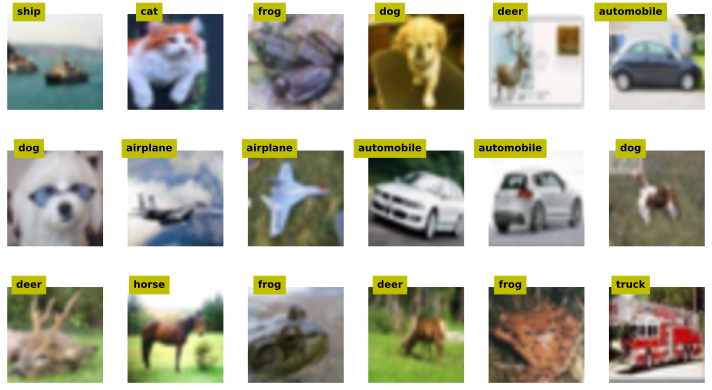

In [43]:
# view some images
# inspect a few random images

X,y = next(iter(train_loader))

fig,axs = plt.subplots(3,6,figsize=(10,6))

for (i,ax) in enumerate(axs.flatten()):

  # extract that image
  pic = torch.squeeze(X.data[i])
  pic = np.transpose(pic, (1,2,0))
  pic = pic/2 + .5 # undo normalization
  
  # and its label
  label = classes[y[i]]

  # and show!
  ax.imshow(pic, cmap='gray')
  ax.text(14,0,label,ha='center',fontweight='bold',color='k',backgroundcolor='y')
  ax.axis('off')

plt.tight_layout()
plt.show()

# Create classes for the discriminator and generator

In [44]:
# Architecture and meta-parameter choices were inspired by https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

In [45]:
class discriminatorNet(nn.Module):
  def __init__(self):
    super().__init__()

    # convolution layers
    self.conv1 = nn.Conv2d(  3, 64, 4, 2, 1, bias=False) # input is 3x64x64, output is 64x32x32
    self.conv2 = nn.Conv2d( 64,128, 4, 2, 1, bias=False) # input is 64x32x32, output is 128x16x16
    self.conv3 = nn.Conv2d(128,256, 4, 2, 1, bias=False) # input is 128x16x16, output is 256x8x8
    self.conv4 = nn.Conv2d(256,512, 4, 2, 1, bias=False) # input is 256x8x8, output is 512x4x4
    self.conv5 = nn.Conv2d(512,  1, 4, 1, 0, bias=False) # input is 512x4x4, output is 1x1x1

    # batchnorm
    self.bn2 = nn.BatchNorm2d(128)
    self.bn3 = nn.BatchNorm2d(256)
    self.bn4 = nn.BatchNorm2d(512)
    
  def forward(self,x):
    x = F.leaky_relu( self.conv1(x) ,.2)
    x = F.leaky_relu( self.conv2(x) ,.2)
    x = self.bn2(x)
    x = F.leaky_relu( self.conv3(x) ,.2)
    x = self.bn3(x)
    x = F.leaky_relu( self.conv4(x) ,.2)
    x = self.bn4(x)
    return torch.sigmoid( self.conv5(x) ).view(-1,1)


dnet = discriminatorNet()
y = dnet(torch.randn(10,3,64,64))
y.shape

torch.Size([10, 1])

torch.Size([10, 3, 64, 64])


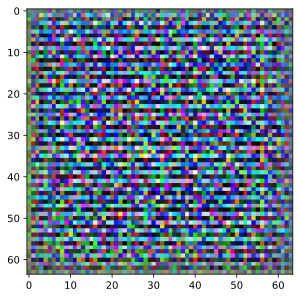

In [46]:
class generatorNet(nn.Module):
  def __init__(self):
    super().__init__()

    # convolution layers
    self.conv1 = nn.ConvTranspose2d(100,512, 4, 1, 0, bias=False) # input is 100x1x1, output is 512x4x4
    self.conv2 = nn.ConvTranspose2d(512,256, 4, 2, 1, bias=False) # input is 512x4x4, output is 256x8x8
    self.conv3 = nn.ConvTranspose2d(256,128, 4, 2, 1, bias=False) # input is 256x8x8, output is 128x16x16
    self.conv4 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False) # input is 128x16x16, output is 64x32x32
    self.conv5 = nn.ConvTranspose2d(64,   3, 4, 2, 1, bias=False) # input is 64x32x32, output is 3x64x64

    # batchnorm
    self.bn1 = nn.BatchNorm2d(512)
    self.bn2 = nn.BatchNorm2d(256)
    self.bn3 = nn.BatchNorm2d(128)
    self.bn4 = nn.BatchNorm2d( 64)


  def forward(self,x):
    x = F.relu( self.bn1(self.conv1(x)) )
    x = F.relu( self.bn2(self.conv2(x)) )
    x = F.relu( self.bn3(self.conv3(x)) )
    x = F.relu( self.bn4(self.conv4(x)) )
    x = torch.tanh( self.conv5(x) )
    return x
    

gnet = generatorNet()
y = gnet(torch.randn(10,100,1,1))
print(y.shape)
img = y[0,:,:,:].squeeze().detach().numpy()
img = np.transpose(img, (1,2,0))
img = img/2 + .5 # undo normalization
plt.imshow(img)

# Train the models!

In [47]:
lossfun = nn.BCELoss()

dnet = discriminatorNet().to(device)
gnet = generatorNet().to(device)

d_optimizer = torch.optim.Adam(dnet.parameters(), lr=.0002, betas=(.5,.999))
g_optimizer = torch.optim.Adam(gnet.parameters(), lr=.0002, betas=(.5,.999))
# d_optimizer = torch.optim.Adam(dnet.parameters(), lr=.0002)
# g_optimizer = torch.optim.Adam(gnet.parameters(), lr=.0002)

In [ ]:
# number of epochs (expressed in number of batches)
# The trainloader has 781 batches (781*64 is nearly 50000, the number of training images)
# With 12 iterations we had overtraining. We realised that a 10/20% was enough. And it was not. The issue was not overtraining
# In the video they did 50 epochs, and still not good results. Some stuff are well done but.. yeah.
# The models are not good enough for this data.
num_epochs = 50 
print(f'Number of epochs: {num_epochs}')
print(f'Number of batches per epoch: {len(train_loader)}')

losses  = []
disDecs = []
batch_counter = 0

for epochi in range(num_epochs):

  for data,labels in train_loader:
    
    # send data to GPU
    data = data.to(device)
    labels = labels.to(device)

    # create labels for real and fake images
    real_labels = torch.ones(batch_size,1).to(device)
    fake_labels = torch.zeros(batch_size,1).to(device)



    ### ---------------- Train the discriminator ---------------- ###

    # forward pass and loss for REAL pictures
    pred_real   = dnet(data)                     # output of discriminator
    d_loss_real = lossfun(pred_real,real_labels) # all labels are 1

    # forward pass and loss for FAKE pictures
    fake_data   = torch.randn(batch_size,100,1,1).to(device) # random numbers to seed the generator
    fake_images = gnet(fake_data)                           # output of generator
    pred_fake   = dnet(fake_images)                         # pass through discriminator
    d_loss_fake = lossfun(pred_fake,fake_labels)            # all labels are 0

    # collect loss (using combined losses)
    d_loss = d_loss_real + d_loss_fake

    # backprop
    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()



    ### ---------------- Train the generator ---------------- ###

    # create fake images and compute loss
    fake_images = gnet( torch.randn(batch_size,100,1,1).to(device) )
    pred_fake   = dnet(fake_images)

    # compute loss
    g_loss = lossfun(pred_fake,real_labels)

    # backprop
    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()


    # collect losses and discriminator decisions
    losses.append([d_loss.item(),g_loss.item()])
    
    d1 = torch.mean((pred_real>.5).float()).detach()
    d2 = torch.mean((pred_fake>.5).float()).detach()
    disDecs.append([d1,d2])

    batch_counter += 1

    msg = f'Finished batch {batch_counter}/{len(train_loader)*num_epochs}'
    sys.stdout.write('\r' + msg)


# convert performance from list to numpy array
d1 = torch.mean((pred_real>.5).float()).detach().cpu().item()
d2 = torch.mean((pred_fake>.5).float()).detach().cpu().item()
disDecs.append([d1, d2])

Number of epochs: 2
Number of batches per epoch: 781
Finished batch 1562/1562

In [58]:
# create a 1D smoothing filter
def smooth(x,k=15):
  return np.convolve(x,np.ones(k)/k,mode='same')

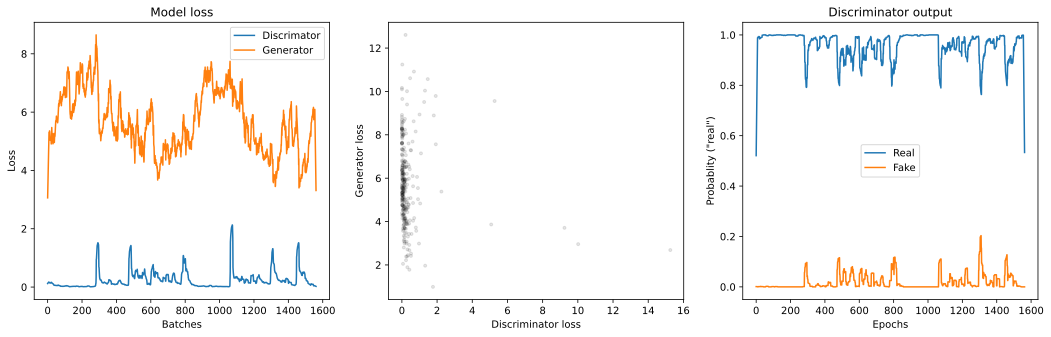

In [59]:
fig,ax = plt.subplots(1,3,figsize=(18,5))

losses = np.array(losses)
disDecs = np.array([[float(d1),float(d2)] for (d1,d2) in disDecs])

ax[0].plot(smooth(losses[:,0]))
ax[0].plot(smooth(losses[:,1]))
ax[0].set_xlabel('Batches')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')
ax[0].legend(['Discrimator','Generator'])
# ax[0].set_xlim([500,2300])
# ax[0].set_ylim([-.5,6])

ax[1].plot(losses[::5,0],losses[::5,1],'k.',alpha=.1)
ax[1].set_xlabel('Discriminator loss')
ax[1].set_ylabel('Generator loss')

ax[2].plot(smooth(disDecs[:,0]))
ax[2].plot(smooth(disDecs[:,1]))
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Probablity ("real")')
ax[2].set_title('Discriminator output')
ax[2].legend(['Real','Fake'])

plt.show()

# Let's see some fake fashion!

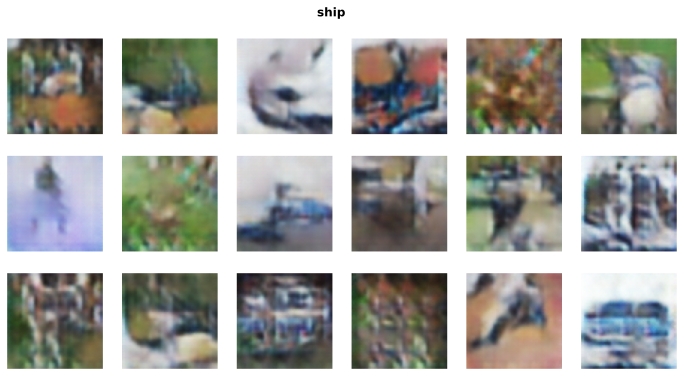

In [60]:
# generate the images from the generator network
gnet.eval()
fake_data = gnet( torch.randn(batch_size,100,1,1).to(device) ).cpu()

# and visualize...
fig,axs = plt.subplots(3,6,figsize=(12,6))
for i,ax in enumerate(axs.flatten()):
  imgs = fake_data[i,:,:,:].detach().numpy()
  imgs = np.transpose(imgs, (1,2,0))
  imgs = imgs/2 + .5 # undo normalization
  ax.imshow(imgs)
  ax.axis('off')

plt.suptitle(classes[labels[i]],y=.95,fontweight='bold')
plt.show()